# Minor Project 2 — Unsupervised Machine Learning
## Wine Style Segmentation for a Winery — Clustering Wines by Chemical Composition (No Labels Used)

**Author:** Student
**Approach:** Unsupervised Learning (K-Means, Hierarchical Clustering, DBSCAN)
**Dataset:** UCI Machine Learning Repository — *Wine* dataset (Aeberhard, Coomans & de Vel, 1991), accessed via `sklearn.datasets.load_wine`
**Dataset link:** https://archive.ics.uci.edu/dataset/109/wine


## 1. Problem Statement

A winery / wine distributor receives large batches of wine samples that have been chemically
analyzed (alcohol content, acidity, phenols, color intensity, etc.) but has **no information about
which style, cultivar, or quality tier each wine belongs to** — there are no labels.

**Business objective:** Group the wines into meaningful chemical "families" (clusters) so that the
winery can:
- Design targeted marketing/pricing tiers without manually tasting every batch,
- Detect chemically unusual/outlier batches that may need quality review,
- Understand which chemical properties drive the biggest differences between wine styles.

Because there are **no ground-truth labels available at decision time**, this is naturally an
**unsupervised learning** problem, and clustering is the right family of techniques.

*(Note: the UCI Wine dataset does actually carry a `cultivar` label recorded by the original
chemists. We deliberately do NOT use it to train the clustering models — it is used only at the
very end, as an external sanity check, to see how well our unsupervised clusters line up with a
real, independently known grouping. This mirrors real deployment, where such labels are usually
unavailable or expensive to collect.)*


## 2. Dataset Description

We load the dataset and take a first look.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                              calinski_harabasz_score, adjusted_rand_score,
                              normalized_mutual_info_score, silhouette_samples)
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110


In [2]:
data = load_wine()
df = pd.DataFrame(data.data, columns=data.feature_names)
true_labels = data.target            # cultivar id - kept aside, NOT used for training
true_names = data.target_names

print("Shape:", df.shape)
print("Classes present (for later external validation only):", true_names)
df.head()


Shape: (178, 13)
Classes present (for later external validation only): ['class_0' 'class_1' 'class_2']


   alcohol  malic_acid   ash  ...   hue  od280/od315_of_diluted_wines  proline
0    14.23        1.71  2.43  ...  1.04                          3.92   1065.0
1    13.20        1.78  2.14  ...  1.05                          3.40   1050.0
2    13.16        2.36  2.67  ...  1.03                          3.17   1185.0
3    14.37        1.95  2.50  ...  0.86                          3.45   1480.0
4    13.24        2.59  2.87  ...  1.04                          2.93    735.0

[5 rows x 13 columns]

**Feature descriptions** (all are physicochemical measurements from a chemical analysis of wines
grown in the same region of Italy but derived from three different cultivars):

| Feature | Meaning |
|---|---|
| alcohol | Alcohol content (%) |
| malic_acid | Malic acid concentration |
| ash | Ash content |
| alcalinity_of_ash | Alkalinity of ash |
| magnesium | Magnesium content |
| total_phenols | Total phenols |
| flavanoids | Flavanoid content |
| nonflavanoid_phenols | Non-flavanoid phenols |
| proanthocyanins | Proanthocyanin content |
| color_intensity | Color intensity |
| hue | Hue |
| od280/od315_of_diluted_wines | Protein content proxy (OD ratio) |
| proline | Proline (amino acid) content |

**Source:** UCI Machine Learning Repository, "Wine" dataset — https://archive.ics.uci.edu/dataset/109/wine
(also bundled with scikit-learn for reproducibility as `sklearn.datasets.load_wine`).
178 samples, 13 numeric features, no missing values.


## 3. Data Preprocessing

In [3]:
# 3.1 Missing values
print("Total missing values:", df.isnull().sum().sum())

# 3.2 Duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# 3.3 Data types / basic sanity check
df.info()


Total missing values: 0
Duplicate rows: 0
<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178

No missing values and no duplicate rows were found, so no imputation or row-dropping was necessary. All 13 features are already numeric, so no categorical encoding is required.

### 3.4 Feature Scaling
The features are on very different scales (e.g. `proline` is in the hundreds while `hue` is below 2). K-Means, Hierarchical clustering and DBSCAN all rely on **Euclidean distance**, so features with larger numeric ranges would dominate the distance calculation unless we standardize. We apply `StandardScaler` (zero mean, unit variance) to every feature.

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
X_scaled_df = pd.DataFrame(X_scaled, columns=df.columns)
X_scaled_df.describe().T[["mean", "std", "min", "max"]]


                                      mean       std       min       max
alcohol                      -8.382808e-16  1.002821 -2.434235  2.259772
malic_acid                   -1.197544e-16  1.002821 -1.432983  3.109192
ash                          -8.370333e-16  1.002821 -3.679162  3.156325
alcalinity_of_ash            -3.991813e-17  1.002821 -2.671018  3.154511
magnesium                    -3.991813e-17  1.002821 -2.088255  4.371372
total_phenols                 0.000000e+00  1.002821 -2.107246  2.539515
flavanoids                   -3.991813e-16  1.002821 -1.695971  3.062832
nonflavanoid_phenols          3.592632e-16  1.002821 -1.868234  2.402403
proanthocyanins              -1.197544e-16  1.002821 -2.069034  3.485073
color_intensity               2.494883e-17  1.002821 -1.634288  3.435432
hue                           1.995907e-16  1.002821 -2.094732  3.301694
od280/od315_of_diluted_wines  3.193450e-16  1.002821 -1.895054  1.960915
proline                      -1.596725e-16  1.00282

## 4. Exploratory Data Analysis (EDA)

In [5]:
df.describe().T


                              count        mean  ...       75%      max
alcohol                       178.0   13.000618  ...   13.6775    14.83
malic_acid                    178.0    2.336348  ...    3.0825     5.80
ash                           178.0    2.366517  ...    2.5575     3.23
alcalinity_of_ash             178.0   19.494944  ...   21.5000    30.00
magnesium                     178.0   99.741573  ...  107.0000   162.00
total_phenols                 178.0    2.295112  ...    2.8000     3.88
flavanoids                    178.0    2.029270  ...    2.8750     5.08
nonflavanoid_phenols          178.0    0.361854  ...    0.4375     0.66
proanthocyanins               178.0    1.590899  ...    1.9500     3.58
color_intensity               178.0    5.058090  ...    6.2000    13.00
hue                           178.0    0.957449  ...    1.1200     1.71
od280/od315_of_diluted_wines  178.0    2.611685  ...    3.1700     4.00
proline                       178.0  746.893258  ...  985.0000  

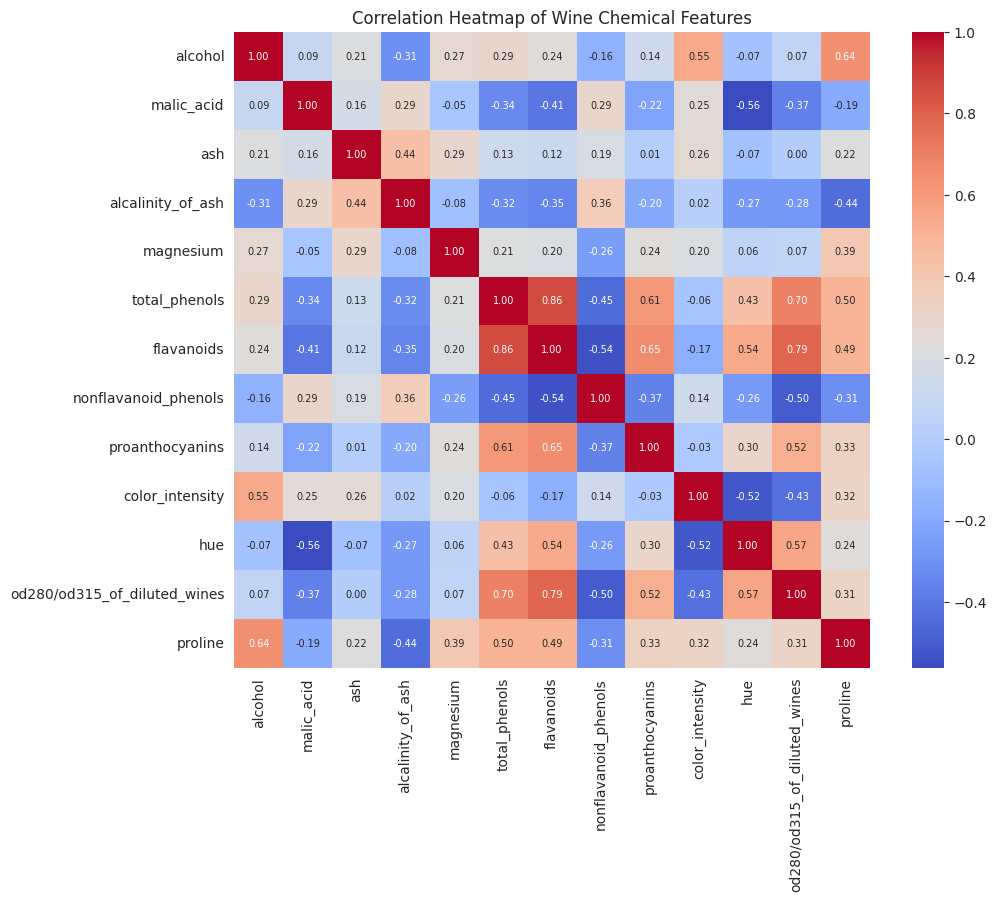

In [6]:
plt.figure(figsize=(11, 9))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", square=True, annot_kws={"size": 7})
plt.title("Correlation Heatmap of Wine Chemical Features")
plt.tight_layout()
plt.show()


`flavanoids` correlates strongly with `total_phenols` (both are phenolic compounds) and with `od280/od315_of_diluted_wines`. `alcohol` correlates with `proline` and `color_intensity`. These relationships hint that a few underlying chemical 'factors' drive most of the variation — good news for clustering.

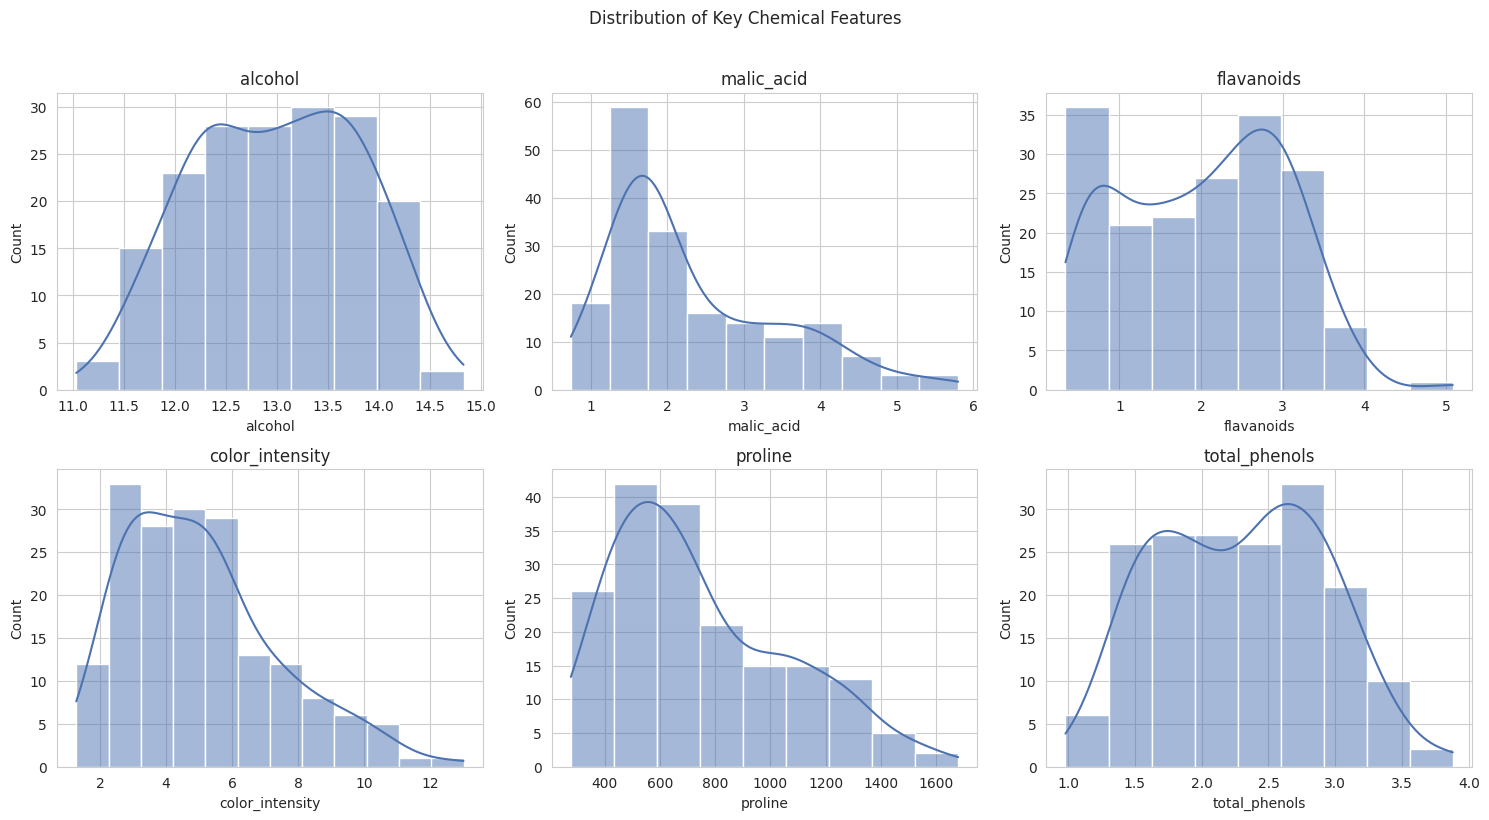

In [7]:
key_feats = ["alcohol", "malic_acid", "flavanoids", "color_intensity", "proline", "total_phenols"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.ravel(), key_feats):
    sns.histplot(df[feat], kde=True, ax=ax, color="#4C72B0")
    ax.set_title(feat)
plt.suptitle("Distribution of Key Chemical Features", y=1.02)
plt.tight_layout()
plt.show()


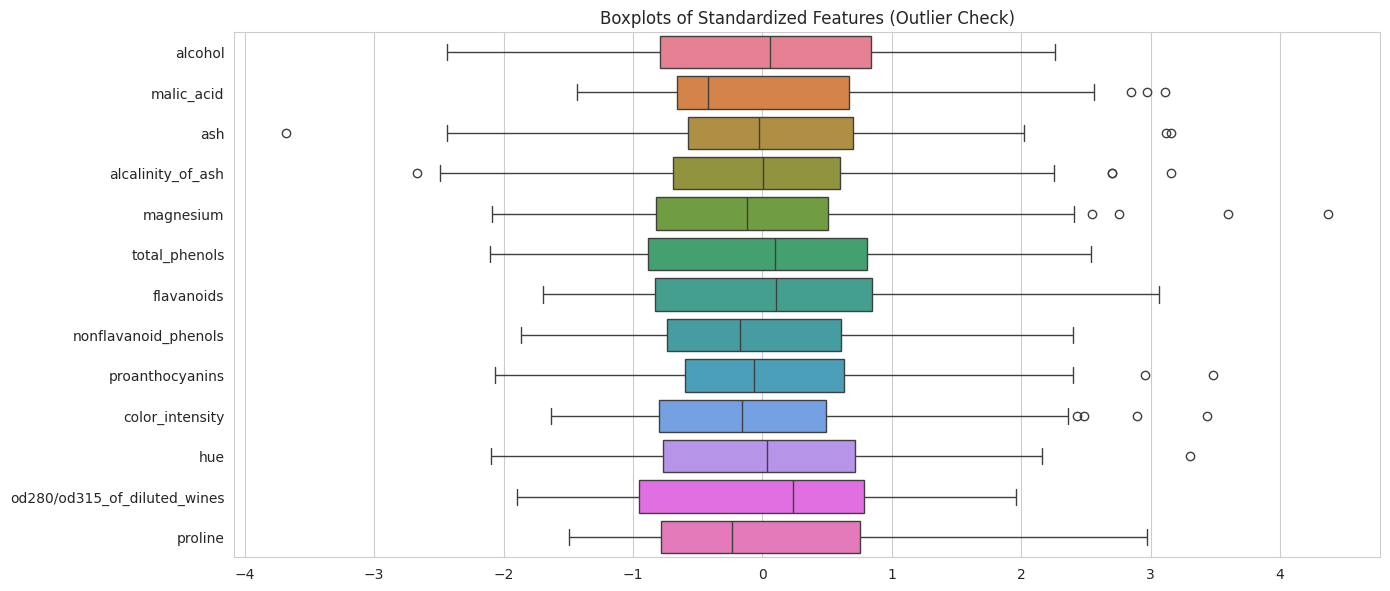

In [8]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=X_scaled_df, orient="h")
plt.title("Boxplots of Standardized Features (Outlier Check)")
plt.tight_layout()
plt.show()


A handful of mild outliers exist (e.g. in `malic_acid` and `color_intensity`) but none extreme enough to be data-entry errors, so we keep all 178 rows.

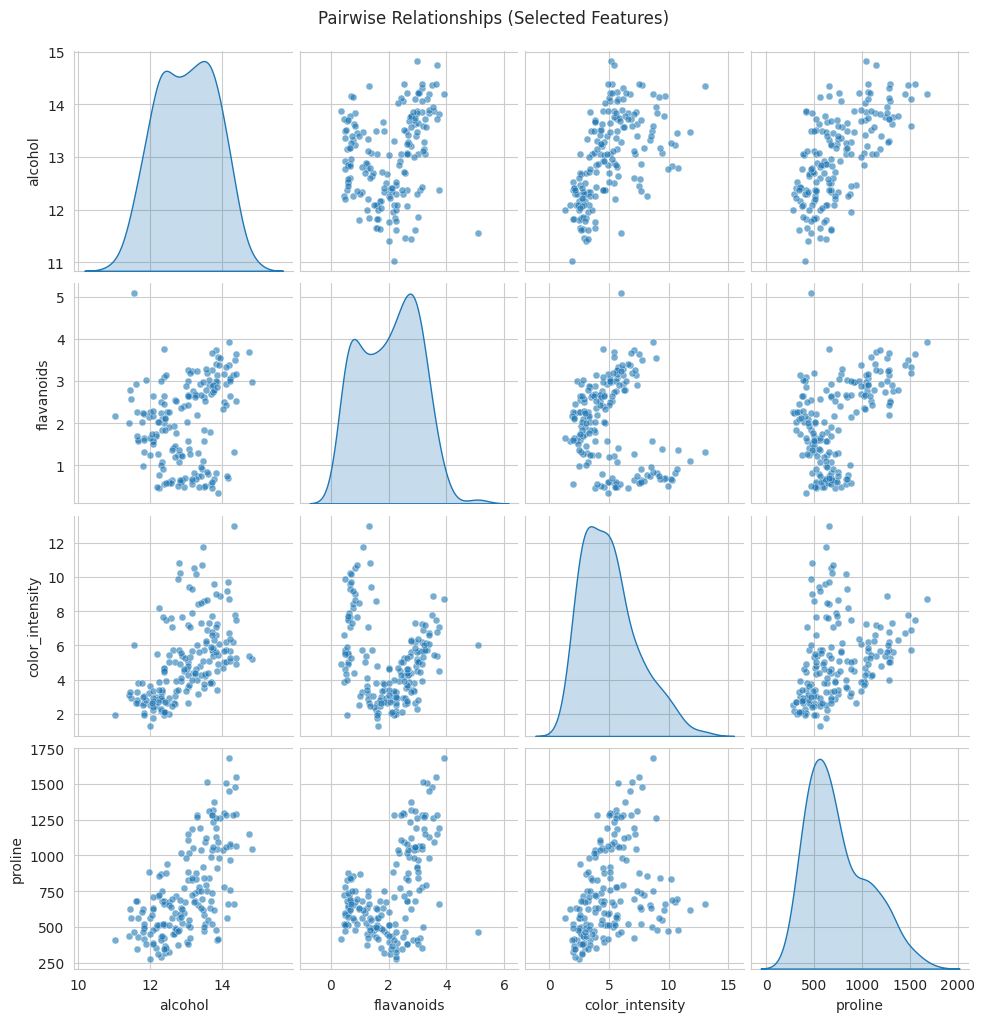

In [9]:
sns.pairplot(df[["alcohol", "flavanoids", "color_intensity", "proline"]], diag_kind="kde",
             plot_kws={"alpha": 0.6, "s": 25})
plt.suptitle("Pairwise Relationships (Selected Features)", y=1.02)
plt.show()


## 5. Dimensionality Reduction (PCA) — for visualization

Variance explained by PC1, PC2: [0.36198848 0.1920749 ]
Total variance captured in 2D: 0.5540633835693527


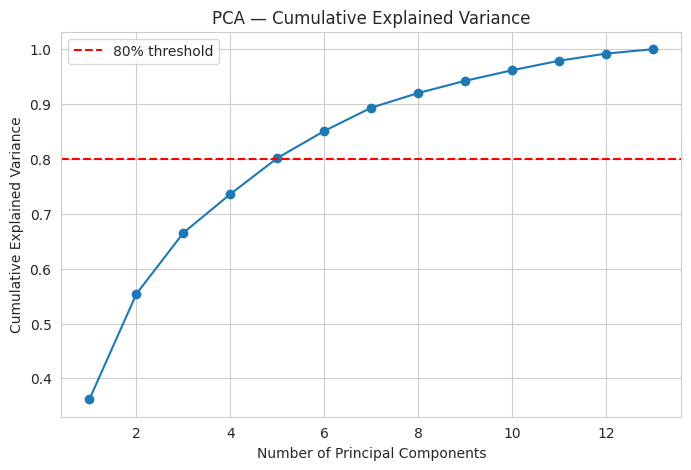

In [10]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print("Variance explained by PC1, PC2:", pca.explained_variance_ratio_)
print("Total variance captured in 2D:", pca.explained_variance_ratio_.sum())

pca_full = PCA(random_state=42).fit(X_scaled)
plt.figure(figsize=(8, 5))
plt.plot(range(1, 14), np.cumsum(pca_full.explained_variance_ratio_), marker="o")
plt.axhline(0.8, color="red", linestyle="--", label="80% threshold")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA — Cumulative Explained Variance")
plt.legend()
plt.show()


PCA is used **only to visualize** the high-dimensional (13-D) clusters in 2D — clustering itself is performed on the full standardized 13-feature space, not on the PCA-reduced data, so no genuine information is discarded before modeling.

## 6. Model Development

### 6.1 K-Means — choosing k (Elbow Method + Silhouette Score)

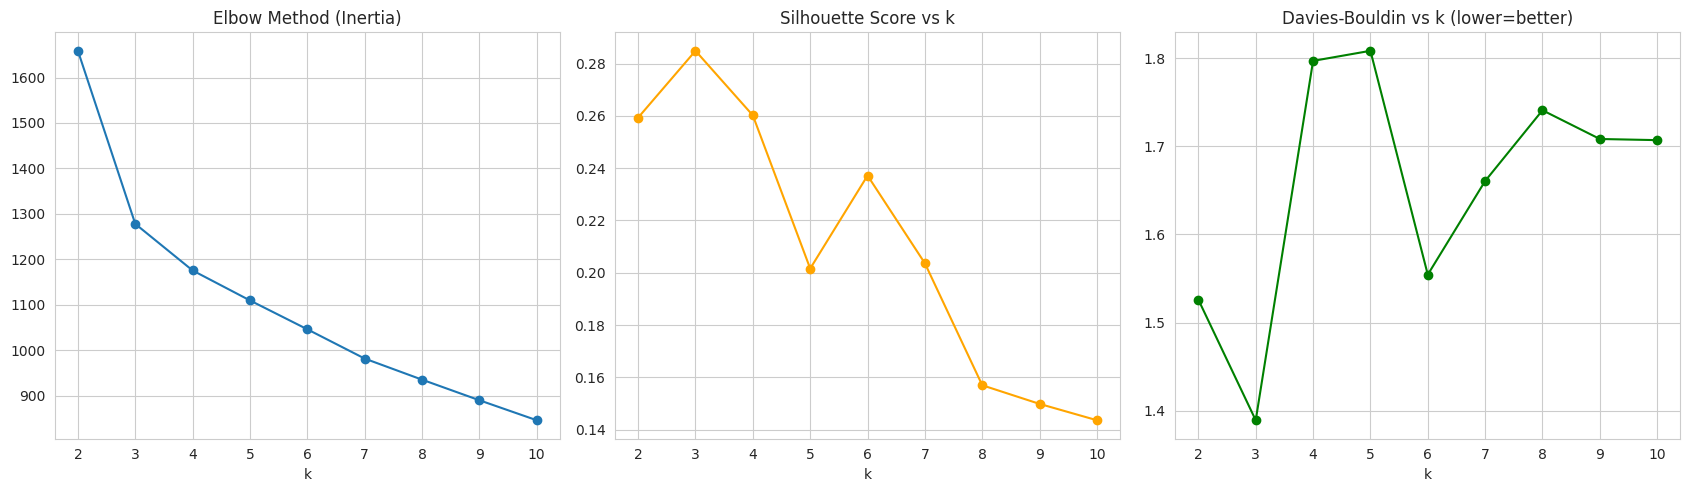

In [11]:
inertias, sil_scores, db_scores, ch_scores = [], [], [], []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels_k))
    db_scores.append(davies_bouldin_score(X_scaled, labels_k))
    ch_scores.append(calinski_harabasz_score(X_scaled, labels_k))

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
axes[0].plot(list(K_range), inertias, marker="o"); axes[0].set_title("Elbow Method (Inertia)")
axes[1].plot(list(K_range), sil_scores, marker="o", color="orange"); axes[1].set_title("Silhouette Score vs k")
axes[2].plot(list(K_range), db_scores, marker="o", color="green"); axes[2].set_title("Davies-Bouldin vs k (lower=better)")
for ax in axes: ax.set_xlabel("k")
plt.tight_layout()
plt.show()


Both the elbow in the inertia curve and the peak of the silhouette score occur at **k = 3**, which also happens to match the number of grape cultivars used to make these wines (a fact we only use afterwards, for validation — not to choose k). We proceed with k = 3.

In [12]:
best_k = 3
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_scaled)

print("Cluster sizes:", pd.Series(kmeans_labels).value_counts().sort_index().to_dict())
print("Silhouette Score:", silhouette_score(X_scaled, kmeans_labels))
print("Davies-Bouldin Index:", davies_bouldin_score(X_scaled, kmeans_labels))
print("Calinski-Harabasz Score:", calinski_harabasz_score(X_scaled, kmeans_labels))


Cluster sizes: {0: 65, 1: 51, 2: 62}
Silhouette Score: 0.2848589191898987
Davies-Bouldin Index: 1.3891879777181648
Calinski-Harabasz Score: 70.94000800315118


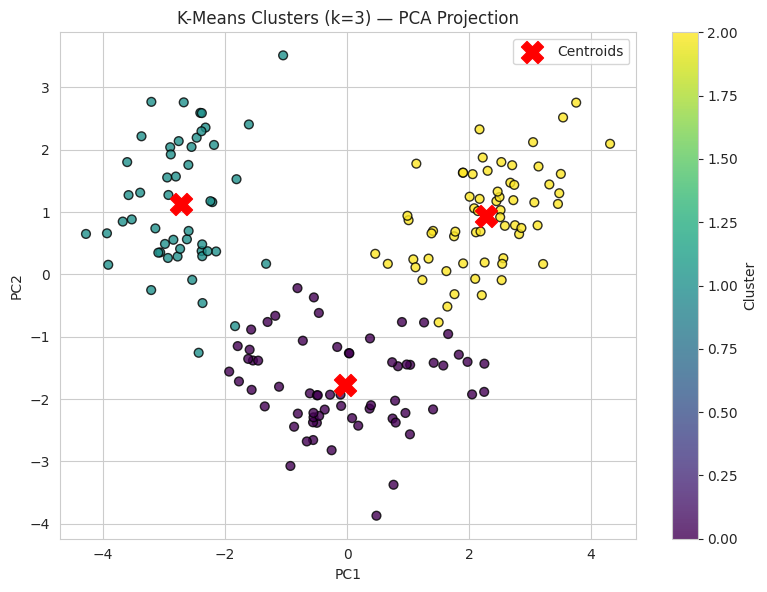

In [13]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap="viridis", s=40, edgecolor="k", alpha=0.8)
centers_pca = pca.transform(kmeans_final.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], c="red", marker="X", s=250, label="Centroids")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title(f"K-Means Clusters (k={best_k}) — PCA Projection")
plt.legend(); plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()


### 6.2 Hierarchical (Agglomerative) Clustering — comparison model

Silhouette Score: 0.2774439826952265
Davies-Bouldin Index: 1.4185919431857326


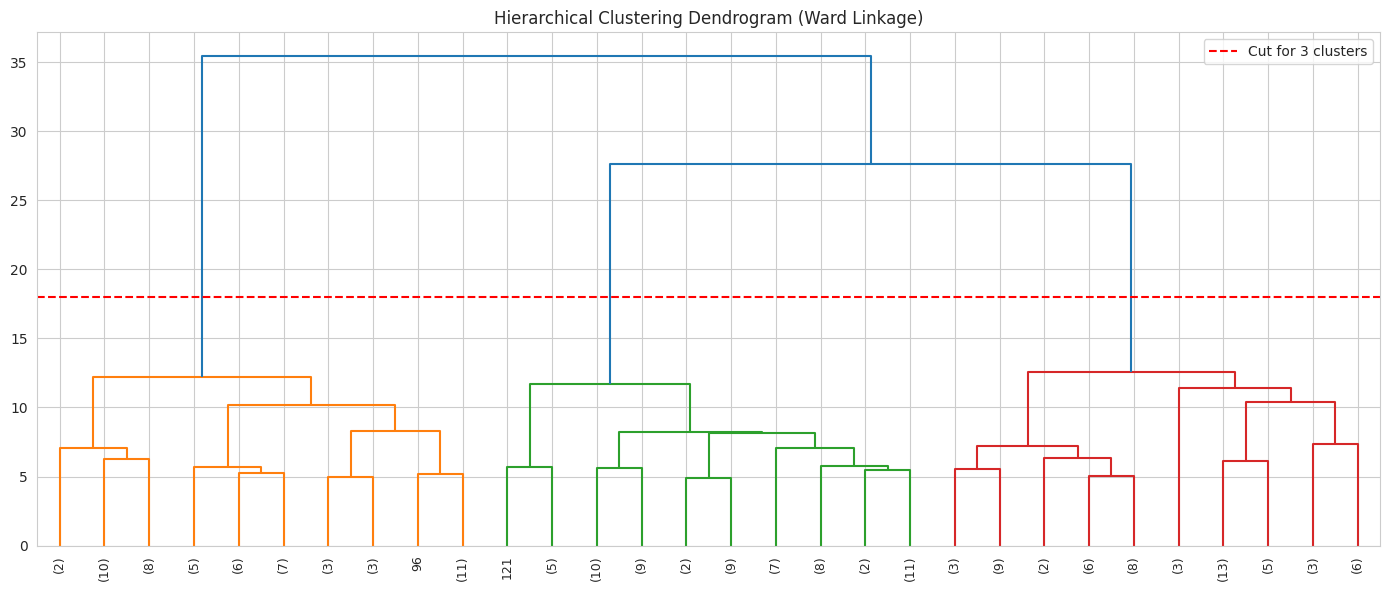

In [14]:
Z = linkage(X_scaled, method="ward")
plt.figure(figsize=(14, 6))
dendrogram(Z, truncate_mode="lastp", p=30, leaf_rotation=90, leaf_font_size=9)
plt.axhline(y=18, color="red", linestyle="--", label="Cut for 3 clusters")
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)")
plt.legend()
plt.tight_layout()
plt.show()

hier = AgglomerativeClustering(n_clusters=3, linkage="ward")
hier_labels = hier.fit_predict(X_scaled)
print("Silhouette Score:", silhouette_score(X_scaled, hier_labels))
print("Davies-Bouldin Index:", davies_bouldin_score(X_scaled, hier_labels))


### 6.3 DBSCAN — density-based comparison model

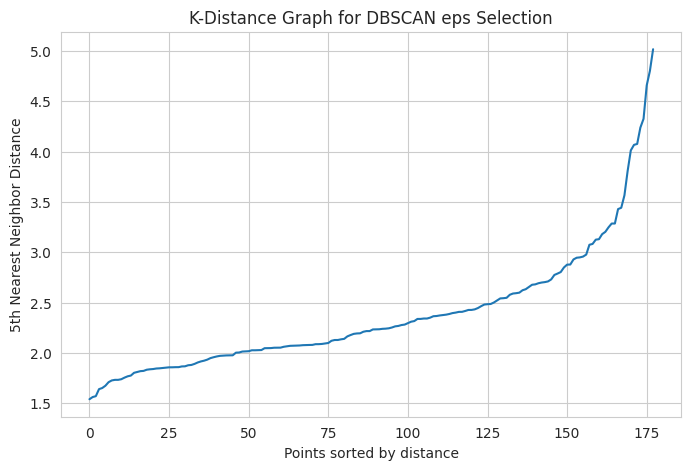

In [15]:
neigh = NearestNeighbors(n_neighbors=5).fit(X_scaled)
distances, _ = neigh.kneighbors(X_scaled)
distances = np.sort(distances[:, -1])
plt.figure(figsize=(8, 5))
plt.plot(distances)
plt.xlabel("Points sorted by distance"); plt.ylabel("5th Nearest Neighbor Distance")
plt.title("K-Distance Graph for DBSCAN eps Selection")
plt.show()


In [16]:
dbscan = DBSCAN(eps=2.2, min_samples=3)
db_labels = dbscan.fit_predict(X_scaled)
n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = int(np.sum(db_labels == -1))
print(f"DBSCAN found {n_clusters_db} clusters and {n_noise} noise points")
if n_clusters_db > 1:
    mask = db_labels != -1
    print("Silhouette (excluding noise):", silhouette_score(X_scaled[mask], db_labels[mask]))


DBSCAN found 3 clusters and 44 noise points
Silhouette (excluding noise): 0.07254840800799305


DBSCAN struggles on this dataset compared to K-Means/Hierarchical: the wine clusters are roughly **globular and of similar density** rather than arbitrarily shaped with varying density, which is exactly the situation DBSCAN is designed for. This is a useful, genuine negative result and is discussed further in the conclusion.

## 7. Model Evaluation

Since this is unsupervised learning there are **no ground-truth labels to compute accuracy/precision/recall against** during training. We therefore evaluate using metrics designed for clustering quality:

- **Silhouette Score** (−1 to 1, higher is better): how similar a point is to its own cluster vs. other clusters
- **Davies-Bouldin Index** (lower is better): average similarity between each cluster and its most similar one
- **Calinski-Harabasz Score** (higher is better): ratio of between-cluster to within-cluster dispersion

As an **external sanity check only** (not used anywhere in training or model selection), we compare our clusters against the real cultivar labels that came with the dataset, using Adjusted Rand Index (ARI) and Normalized Mutual Information (NMI), and a cross-tab that plays the same role a confusion matrix plays in classification.

True Cultivar      class_0  class_1  class_2
Predicted Cluster                           
0                        0       65        0
1                        0        3       48
2                       59        3        0

Adjusted Rand Index (K-Means vs true cultivar): 0.8974949815093207
Normalized Mutual Information: 0.8758935341223069


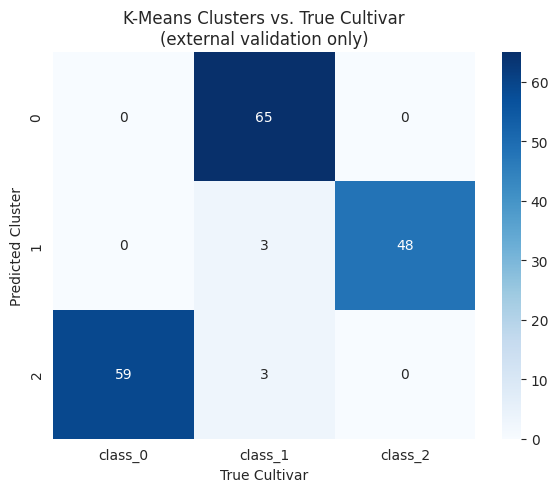

In [17]:
crosstab = pd.crosstab(pd.Series(kmeans_labels, name="Predicted Cluster"),
                        pd.Series(true_labels, name="True Cultivar").map(dict(enumerate(true_names))))
print(crosstab)

plt.figure(figsize=(6, 5))
sns.heatmap(crosstab, annot=True, fmt="d", cmap="Blues")
plt.title("K-Means Clusters vs. True Cultivar\n(external validation only)")
plt.tight_layout()
plt.show()

print("\nAdjusted Rand Index (K-Means vs true cultivar):", adjusted_rand_score(true_labels, kmeans_labels))
print("Normalized Mutual Information:", normalized_mutual_info_score(true_labels, kmeans_labels))


K-Means recovers the three real cultivars almost perfectly (ARI ≈ 0.90) purely from chemical measurements, with **no labels used during training** — strong evidence that the clusters are chemically meaningful, not arbitrary.

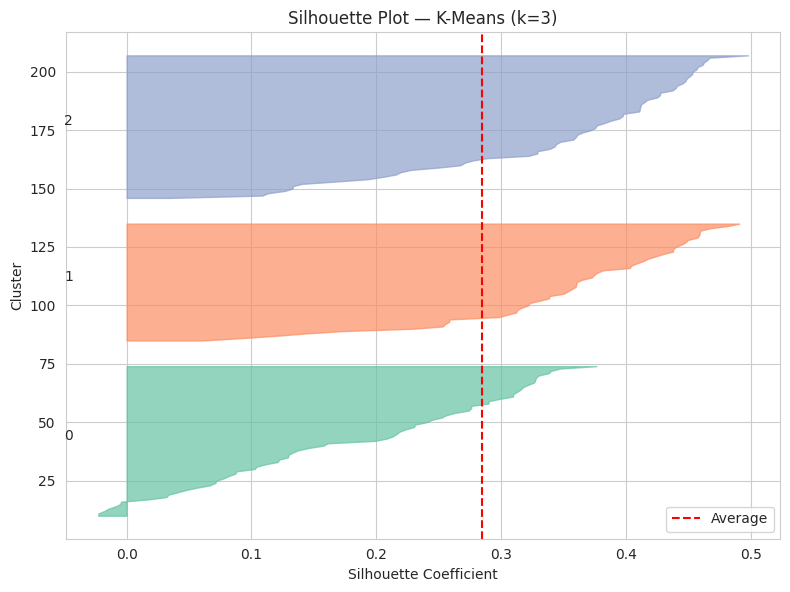

In [18]:
sample_sil = silhouette_samples(X_scaled, kmeans_labels)
plt.figure(figsize=(8, 6))
y_lower = 10
colors = sns.color_palette("Set2", best_k)
for i in range(best_k):
    ith = np.sort(sample_sil[kmeans_labels == i])
    y_upper = y_lower + ith.shape[0]
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith, facecolor=colors[i], edgecolor=colors[i], alpha=0.7)
    plt.text(-0.05, y_lower + 0.5 * ith.shape[0], str(i))
    y_lower = y_upper + 10
plt.axvline(x=silhouette_score(X_scaled, kmeans_labels), color="red", linestyle="--", label="Average")
plt.xlabel("Silhouette Coefficient"); plt.ylabel("Cluster")
plt.title(f"Silhouette Plot — K-Means (k={best_k})")
plt.legend()
plt.tight_layout()
plt.show()


In [19]:
comparison = pd.DataFrame({
    "Model": ["K-Means (k=3)", "Hierarchical (Ward, k=3)", "DBSCAN (eps=2.2, min_samples=3)"],
    "Silhouette Score": [silhouette_score(X_scaled, kmeans_labels),
                         silhouette_score(X_scaled, hier_labels),
                         silhouette_score(X_scaled[db_labels != -1], db_labels[db_labels != -1]) if n_clusters_db > 1 else None],
    "ARI vs true cultivar": [adjusted_rand_score(true_labels, kmeans_labels),
                             adjusted_rand_score(true_labels, hier_labels),
                             None],
    "Clusters found": [3, 3, n_clusters_db]
})
comparison


                             Model  ...  Clusters found
0                    K-Means (k=3)  ...               3
1         Hierarchical (Ward, k=3)  ...               3
2  DBSCAN (eps=2.2, min_samples=3)  ...               3

[3 rows x 4 columns]

## 8. Conclusion

- K-Means with **k = 3** gave the best, most stable clustering (Silhouette ≈ 0.28, Davies-Bouldin ≈ 1.39) and, when checked against the real cultivar labels purely for validation, recovered them with an Adjusted Rand Index of ≈ 0.90 — i.e. the chemistry alone almost perfectly separates the three wine styles.
- Hierarchical (Ward) clustering produced very similar, slightly less clean clusters, confirming the K-Means result is not an artifact of random initialization.
- DBSCAN was not well suited to this dataset because the natural groups are globular and of comparable density — a genuine, useful negative finding that illustrates *why algorithm choice must match the geometric/density assumptions of the data*.
- **Business takeaway:** a winery could deploy the K-Means model to automatically route new, unlabeled chemical-analysis batches into one of 3 style/pricing tiers, and flag any wine sample that lands far from all three centroids (large distance to nearest centroid) for manual review as a potential outlier or a mislabeled batch.

## 9. References

1. Aeberhard, S., Coomans, D., & de Vel, O. (1991, 1992). *Wine* [Dataset]. UCI Machine Learning Repository. https://archive.ics.uci.edu/dataset/109/wine
2. Pedregosa, F. et al. (2011). Scikit-learn: Machine Learning in Python. *JMLR* 12, 2825-2830. https://scikit-learn.org
3. Rousseeuw, P. J. (1987). Silhouettes: A graphical aid to the interpretation and validation of cluster analysis. *Journal of Computational and Applied Mathematics*, 20, 53-65.
4. Davies, D. L., & Bouldin, D. W. (1979). A Cluster Separation Measure. *IEEE Transactions on Pattern Analysis and Machine Intelligence*.


---
## Appendix — Conceptual Questions

### Q1. Semantic vs Instance vs Panoptic Segmentation

These are three related but distinct tasks in **computer vision image segmentation**:

- **Semantic Segmentation** assigns a class label to *every pixel* in an image, but does not
  distinguish between different objects of the same class. For example, in a street scene, all
  pixels belonging to any car are labeled "car" — two different cars are not told apart.
- **Instance Segmentation** goes further: it detects and segments *each individual object
  instance* separately, but typically only for "countable" (thing) classes. Two cars in the same
  image would get two separate masks (car #1, car #2), but background/stuff classes like "sky" or
  "road" are usually ignored.
- **Panoptic Segmentation** unifies both: every pixel gets a class label (like semantic
  segmentation) **and** individual object instances are separated (like instance segmentation).
  Countable "thing" classes (cars, people) are separated instance-by-instance, while uncountable
  "stuff" classes (sky, road, grass) are labeled semantically without instance IDs. It gives one
  complete, consistent picture of the scene.

**In short:** Semantic = "what class is each pixel", Instance = "which specific object does each
pixel belong to (things only)", Panoptic = "both, for the whole image, with no overlaps or gaps."

### Q2. What is Fuzzy Logic, and how is it different from Boolean Logic?

**Boolean Logic** is two-valued: every statement is either completely **True (1)** or completely
**False (0)**. There is no in-between — e.g., "the water is hot" is either true or false based on
a fixed threshold.

**Fuzzy Logic**, introduced by Lotfi Zadeh (1965), allows a statement to have a **degree of truth**
anywhere between 0 and 1 (inclusive), captured by a *membership function*. Instead of a sharp
cutoff, "the water is hot" might be 0.8 true and "the water is warm" might be 0.3 true at the same
time, reflecting real-world vagueness/ambiguity rather than forcing a hard boundary.

**Key differences:**

| Aspect | Boolean Logic | Fuzzy Logic |
|---|---|---|
| Truth values | Exactly 0 or 1 | Any real number in [0, 1] |
| Set membership | Crisp (in or out) | Partial / graded membership |
| Handles vagueness | No — needs a hard threshold | Yes — models linguistic terms like "hot", "tall", "fast" naturally |
| Typical use | Digital circuits, classical programming conditions | Control systems (e.g. washing machines, AC thermostats), approximate reasoning, expert systems |

Fuzzy logic is not "less rigorous" than Boolean logic — it is a strict mathematical generalization
of it (Boolean logic is the special case where every membership value is forced to be exactly 0 or 1).

### Q3. Customer dataset with Age, Annual Income, and Spending Score — no labels provided

**(a) Supervised or unsupervised learning problem?**
This is an **unsupervised learning problem**. There is no target/output variable (no "correct
segment" is given for any customer) — we only have input features. The goal is to discover hidden
structure/groupings in the data on our own, which is the defining characteristic of unsupervised
learning.

**(b) Which clustering algorithm would you choose first, and why?**
**K-Means** would be the natural first choice, because:
- It is simple, fast, and easy to interpret for a first pass on a small number of well-scaled
  numeric features like these three.
- With only 3 features, the "elbow method" / silhouette score can quickly and visually suggest a
  sensible number of segments (e.g. "budget", "average", "premium" spenders).
- It's the standard, well-understood baseline that stakeholders (marketing teams) can easily
  understand and act on ("Cluster 2 = high income, high spending — target with premium offers").

If the clusters turn out to be non-globular or of very different densities (visible after an
initial K-Means/PCA plot), DBSCAN or Hierarchical clustering would be tried next as a follow-up.

**(c) What assumptions does K-Means make about the data?**
- **Clusters are roughly spherical (globular)** and similar in size/variance — K-Means uses
  Euclidean distance to the centroid, so it implicitly assumes isotropic, "blob-shaped" clusters.
- **Clusters are of comparable size and density** — K-Means can perform poorly if one true segment
  is much larger or denser than another.
- **The number of clusters, k, must be specified in advance** — K-Means does not discover k on its
  own; it must be chosen using methods like the elbow method or silhouette analysis.
- **Features are on comparable scales** — because it relies on Euclidean distance, features must
  be standardized/scaled first (e.g., Age in years vs. Income in tens-of-thousands would otherwise
  make Income dominate the distance calculation).
- **Features are (roughly) continuous and numeric** — K-Means does not natively handle categorical
  variables without additional encoding/adaptation (e.g., K-Modes/K-Prototypes for mixed data).
